# Mercedes-Benz Greener Manufacturing

## Predicting Automotive Test-Bench Time Using Machine Learning

**Author:** Mohamed Elbadry  
**Project type:** Supervised Machine Learning – Regression

## 1. Business Understanding

Mercedes-Benz manufactures vehicles with many possible feature configurations.
Before entering the market, each configuration must pass a series of tests on a
test bench. Some configurations require considerably more testing time than
others, which can affect planning, resource utilisation, costs, and production
efficiency.

### Business Objective

The objective of this project is to predict the test-bench time of a vehicle
configuration based on its available features.

A reliable prediction could help Mercedes-Benz to:

- improve test-bench planning;
- identify potentially time-consuming configurations;
- reduce waiting times and bottlenecks;
- improve resource utilisation;
- support a more efficient and sustainable testing process.

### Stakeholders

- Test and validation managers
- Test-bench planners
- Production planners
- Engineering teams
- Quality management

### Machine Learning Task

This is a supervised **regression problem**.

- **Target variable:** `y`
- **Prediction:** Test-bench time
- **Primary evaluation metric:** R²
- **Additional evaluation metrics:** RMSE and MAE

# Mercedes-Benz: Nachhaltigere Fertigung

## Vorhersage der Prüfstandsdauer für Fahrzeuge mittels Machine Learning

**Autor:** Mohamed Elbadry
**Projekttyp:** Überwachtes Lernen (Supervised Learning) – Regression

## 1. Geschäftlicher Kontext

Mercedes-Benz fertigt Fahrzeuge mit einer Vielzahl möglicher Ausstattungskonfigurationen.
Vor der Markteinführung muss jede Konfiguration eine Reihe von Tests auf einem
Prüfstand durchlaufen. Manche Konfigurationen erfordern deutlich mehr Prüfzeit als
andere, was sich auf Planung, Ressourcenauslastung, Kosten und Produktionseffizienz
auswirken kann.

### Geschäftsziel

Ziel dieses Projekts ist es, die Prüfstandsdauer einer Fahrzeugkonfiguration auf
Basis ihrer verfügbaren Ausstattungsmerkmale vorherzusagen.

Eine zuverlässige Vorhersage könnte Mercedes-Benz dabei helfen:

- die Prüfstandsplanung zu optimieren;
- potenziell zeitintensive Konfigurationen zu identifizieren;
- Wartezeiten und Engpässe zu reduzieren;
- die Ressourcenauslastung zu verbessern;
- einen effizienteren und nachhaltigeren Prüfprozess zu unterstützen.

### Stakeholder

- Leiter der Bereiche Erprobung und Validierung
- Prüfstandsplaner
- Produktionsplaner
- Entwicklungsteams
- Qualitätsmanagement

### Machine-Learning-Aufgabe

Es handelt sich um ein Problem der **überwachten Regression**.

- **Zielvariable:** `y`
- **Vorhersage:** Prüfstandsdauer
- **Primäre Bewertungsmetrik:** R²
- **Zusätzliche Bewertungsmetriken:** RMSE und MAE

In [14]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


In [15]:
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)

RANDOM_STATE = 42

## 2. Data Understanding

The dataset contains anonymised vehicle configuration features and the
corresponding test-bench time.

Three files are provided:

- `train.csv`: training features and the target variable `y`;
- `test.csv`: unseen vehicle configurations without the target;
- `sample_submission.csv`: required structure for a Kaggle submission.

The original competition data remains unchanged in the `data/raw` directory.


Der Datensatz enthält anonymisierte Merkmale der Fahrzeugkonfiguration sowie die
entsprechende Prüfstandsdauer.

Es werden drei Dateien bereitgestellt:

- `train.csv`: Trainingsmerkmale und die Zielvariable `y`;
- `test.csv`: unbekannte Fahrzeugkonfigurationen ohne Zielvariable;
- `sample_submission.csv`: erforderliche Struktur für eine Kaggle-Einreichung.

Die ursprünglichen Wettbewerbsdaten bleiben im Verzeichnis `data/raw` unverändert.

In [ ]:
# Path stammt aus der Bibliothek pathlib. Damit können wir Dateipfade sauber und unabhängig vom Betriebssystem erstellen.
DATA_DIR = Path("data/raw")

# Pfade zu den Dateien erzeugen:
train_path = DATA_DIR / "train.csv"
test_path = DATA_DIR / "test.csv"
submission_path = DATA_DIR / "sample_submission.csv"

# CSV-Dateien mit Pandas laden. pd.read_csv() liest eine CSV-Datei ein und erzeugt daraus einen Pandas-DataFrame.
train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)
submission_df = pd.read_csv(submission_path)

In [17]:
print(f"Training data shape: {train_df.shape}")
print(f"Test data shape: {test_df.shape}")
print(f"Submission shape: {submission_df.shape}")

Training data shape: (4209, 378)
Test data shape: (4209, 377)
Submission shape: (4209, 2)


### Dataset Dimensions

The training dataset contains 4,209 vehicle configurations and 378 columns.
The test dataset contains the same number of observations but one fewer column
because the target variable `y` is not available for the test data.

The sample submission contains the vehicle identifier and the predicted
test-bench time.

The dataset has substantially more features than observations. Therefore,
feature selection, regularisation, and careful cross-validation may be important
for building a model that generalises well.

### Abmessungen des Datensatzes

Der Trainingsdatensatz umfasst 4.209 Fahrzeugkonfigurationen und 378 Spalten.
Der Testdatensatz enthält die gleiche Anzahl an Beobachtungen, jedoch eine Spalte weniger,
da die Zielvariable `y` für die Testdaten nicht verfügbar ist.

Die Beispiel-Einreichung enthält die Fahrzeugkennung sowie die vorhergesagte
Prüfstandzeit.

Der Datensatz weist deutlich mehr Merkmale als Beobachtungen auf. Daher können
Merkmalsauswahl, Regularisierung und eine sorgfältige Kreuzvalidierung wichtig
für die Erstellung eines Modells sein, das gut generalisiert.

Untersuchung der Datenqualität
- Konstanten definieren

Hier speichern wir die wichtigsten Spaltennamen in Konstanten:

- TARGET: vorherzusagende Zielvariable
- ID_COLUMN: eindeutige Identifikationsnummer jeder Zeile

Die Namen sind großgeschrieben, weil sie sich während des Projekts nicht verändern sollen. Das ist eine übliche Python-Konvention.

In [18]:
TARGET = "y"
ID_COLUMN = "ID"

# zeige den Datentyp jeder Spalte und zähle wie oft jeder Datentyp vorkommt.
print("Training data types:")
print(train_df.dtypes.value_counts())

# prüfe jede einzelne Zelle und zähle die fehlenden Werte (NaN) pro Spalte. Mit einem zweiten .sum() werden die fehlenden Werte des gesamten DataFrames zusammengerechnet.
print("\nMissing values:")
print(f"Training data: {train_df.isna().sum().sum()}")
print(f"Test data: {test_df.isna().sum().sum()}")

print("\nDuplicates:")
print(f"Duplicate training rows: {train_df.duplicated().sum()}")
print(f"Duplicate training IDs: {train_df[ID_COLUMN].duplicated().sum()}")
print(f"Duplicate test IDs: {test_df[ID_COLUMN].duplicated().sum()}")

Training data types:
int64      369
str          8
float64      1
Name: count, dtype: int64

Missing values:
Training data: 0
Test data: 0

Duplicates:
Duplicate training rows: 0
Duplicate training IDs: 0
Duplicate test IDs: 0


### Spaltentypen bestimmen

- train_df.select_dtypes(include="object"): wählt alle Text- beziehungsweise Kategoriespalten aus.
- .columns: liefert deren Spaltennamen.
- tolist(): wandelt die Spaltennamen in eine normale Python-Liste um. Das Ergebnis könnte beispielsweise so aussehen: ["X0", "X1", "X2", "X3", "X4", "X5", "X6", "X8"]


In [20]:
# Kategoriale Spalten auswählen:
categorical_columns = train_df.select_dtypes(
    include=["object", "string"]
).columns.tolist()

# Feature-Spalten bestimmen:
feature_columns = train_df.drop(columns=TARGET).columns.tolist()

# Anzahl der Features ausgeben:
print(f"Number of features: {len(feature_columns)}")
print(f"Categorical columns: {len(categorical_columns)}")
print(f"Numeric columns including ID and target: {len(numeric_columns)}")

# Namen der kategorialen Spalten anzeigen:
print(f"\nCategorical column names: {categorical_columns}")

Number of features: 377
Categorical columns: 8
Numeric columns including ID and target: 370

Categorical column names: ['X0', 'X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X8']


### Feature Types

The dataset contains 377 potential input features:

- 8 categorical features: `X0`, `X1`, `X2`, `X3`, `X4`, `X5`, `X6`, and `X8`;
- 369 numerical features, including the identifier `ID`;
- one continuous target variable: `y`.

Most numerical features are anonymised binary indicators. The categorical
features must be encoded before they can be used by most machine learning
algorithms.

The `ID` column is an identifier rather than a meaningful vehicle feature.
Therefore, it will not be used for model training.

### Arten von Merkmalen

Der Datensatz enthält 377 potenzielle Eingabemerkmale:

- 8 kategoriale Merkmale: `X0`, `X1`, `X2`, `X3`, `X4`, `X5`, `X6` und `X8`;
- 369 numerische Merkmale, einschließlich der Kennung `ID`;
- eine stetige Zielvariable: `y`.

Bei den meisten numerischen Merkmalen handelt es sich um anonymisierte binäre Indikatoren. Die kategorialen
Merkmale müssen kodiert werden, bevor sie von den meisten Algorithmen des maschinellen Lernens
verwendet werden können.

Die Spalte `ID` dient als Kennung und nicht als aussagekräftiges Fahrzeugmerkmal.
Daher wird sie nicht für das Modelltraining verwendet.

In [21]:
train_df[TARGET].describe()

count    4209.000000
mean      100.669318
std        12.679381
min        72.110000
25%        90.820000
50%        99.150000
75%       109.010000
max       265.320000
Name: y, dtype: float64

### Target Variable

The target variable `y` represents the time a vehicle configuration spends on
the test bench.

The average test time is approximately 100.67, while the median is 99.15. The
middle 50% of observations range from 90.82 to 109.01.

The maximum value of 265.32 is considerably higher than the third quartile.
This indicates that the target distribution may contain unusually high values
or outliers. These observations will be examined before deciding whether any
treatment is appropriate.

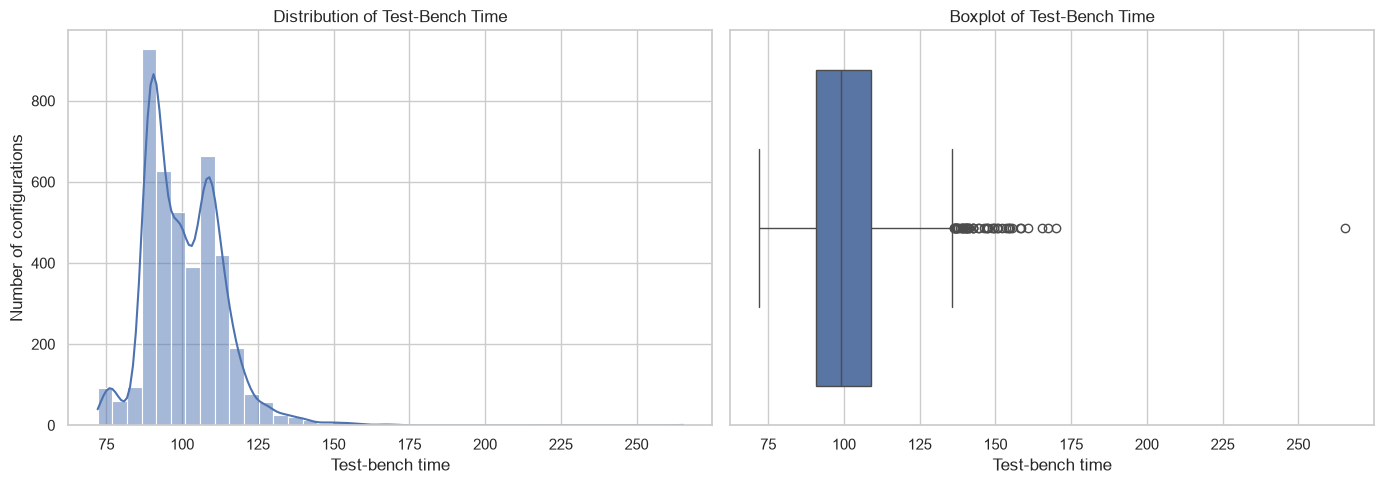

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    data=train_df,
    x=TARGET,
    bins=40,
    kde=True,
    ax=axes[0],
)
axes[0].set_title("Distribution of Test-Bench Time")
axes[0].set_xlabel("Test-bench time")
axes[0].set_ylabel("Number of configurations")

sns.boxplot(
    data=train_df,
    x=TARGET,
    ax=axes[1],
)
axes[1].set_title("Boxplot of Test-Bench Time")
axes[1].set_xlabel("Test-bench time")

plt.tight_layout()
plt.show()

In [23]:
# Ausreißer mit der IQR-Methode zählen:
q1 = train_df[TARGET].quantile(0.25)
q3 = train_df[TARGET].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outlier_mask = (
    (train_df[TARGET] < lower_bound)
    | (train_df[TARGET] > upper_bound)
)

number_of_outliers = outlier_mask.sum()
outlier_percentage = number_of_outliers / len(train_df) * 100

print(f"IQR: {iqr:.2f}")
print(f"Lower boundary: {lower_bound:.2f}")
print(f"Upper boundary: {upper_bound:.2f}")
print(f"Number of potential outliers: {number_of_outliers}")
print(f"Percentage of potential outliers: {outlier_percentage:.2f}%")

IQR: 18.19
Lower boundary: 63.53
Upper boundary: 136.30
Number of potential outliers: 50
Percentage of potential outliers: 1.19%


### Potential Outliers

Using the interquartile range method, observations below 63.53 or above 136.30
are classified as potential outliers.

No observations fall below the lower boundary. However, 50 observations exceed
the upper boundary, representing approximately 1.19% of the training data.

These observations are not removed at this stage. They may represent genuine
vehicle configurations that require unusually long test-bench times. Because
such configurations could be operationally important, the baseline model will
first be evaluated on the complete dataset. Their effect on model performance
will be investigated later during error analysis.

In [24]:
model_features = train_df.drop(
    columns=[ID_COLUMN, TARGET]
)

unique_values = model_features.nunique().sort_values()
constant_columns = unique_values[
    unique_values == 1
].index.tolist()

print(f"Model features before cleaning: {model_features.shape[1]}")
print(f"Constant columns: {len(constant_columns)}")
print(f"Constant column names: {constant_columns}")

Model features before cleaning: 376
Constant columns: 12
Constant column names: ['X290', 'X235', 'X297', 'X11', 'X347', 'X107', 'X233', 'X268', 'X293', 'X330', 'X289', 'X93']


In [25]:
train_df[constant_columns].nunique()

X290    1
X235    1
X297    1
X11     1
X347    1
X107    1
X233    1
X268    1
X293    1
X330    1
X289    1
X93     1
dtype: int64

In [26]:
train_df[constant_columns].iloc[0]

X290    0
X235    0
X297    0
X11     0
X347    0
X107    0
X233    0
X268    0
X293    0
X330    0
X289    0
X93     0
Name: 0, dtype: int64

In [27]:
train_df[["ID", "y"]].head(10)

,ID,y
0,0,130.81
1,6,88.53
2,7,76.26
3,9,80.62
4,13,78.02
5,18,92.93
6,24,128.76
7,25,91.91
8,27,108.67
9,30,126.99


## 3. Data Preparation

The original training dataset is divided into features and the target variable.

The `ID` column is excluded because it is only an identifier and does not
describe a vehicle configuration. The target variable `y` is stored separately.

The labelled data is then divided into:

- a training set used to fit the models;
- a validation set used to evaluate predictions on unseen observations.

The official Kaggle `test.csv` is not used for model evaluation because its
true target values are not available. It will only be used after the final model
has been selected.

In [45]:
from sklearn.dummy import DummyRegressor
from sklearn.metrics import (
    mean_absolute_error,
    r2_score,
    root_mean_squared_error,
)
from sklearn.model_selection import train_test_split


### Features und Target trennen

In [47]:
# Create the feature matrix.
# ID is removed because it is an identifier, not a vehicle feature.
X = train_df.drop(columns=[ID_COLUMN, TARGET]).copy()

# Create the target vector.
y = train_df[TARGET].copy()

print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")

Feature matrix shape: (4209, 376)
Target vector shape: (4209,)


### Training und Validierung aufteilen

### Train-Validation Split

Twenty percent of the labelled observations are reserved as a validation set.
The remaining eighty percent are used for model training.

A fixed random state ensures that the same observations are selected every time
the notebook is executed. This makes the results reproducible.

The Kaggle test dataset remains completely separate and is not used during
model development.

In [48]:
VALIDATION_SIZE = 0.20

X_train, X_validation, y_train, y_validation = train_test_split(
    X,
    y,
    test_size=VALIDATION_SIZE,
    random_state=RANDOM_STATE,
)

print(f"Training features: {X_train.shape}")
print(f"Validation features: {X_validation.shape}")
print(f"Training target: {y_train.shape}")
print(f"Validation target: {y_validation.shape}")


Training features: (3367, 376)
Validation features: (842, 376)
Training target: (3367,)
Validation target: (842,)


### Konstanten nur im Trainingsdatensatz bestimmen

In [50]:
# Count the number of distinct values in every training feature. Zähle die Anzahl der eindeutigen Werte in jedem Trainingsmerkmal.
training_unique_counts = X_train.nunique(dropna=False)

# Identify features that contain only one distinct value. Identifiziere die Merkmale, die nur einen einzigen eindeutigen Wert enthalten.
constant_columns = training_unique_counts[
    training_unique_counts == 1
].index.tolist()

print(f"Features before constant removal: {X_train.shape[1]}")
print(f"Constant features identified: {len(constant_columns)}")
print(f"Constant feature names: {constant_columns}")

Features before constant removal: 376
Constant features identified: 13
Constant feature names: ['X11', 'X93', 'X107', 'X233', 'X235', 'X268', 'X288', 'X289', 'X290', 'X293', 'X297', 'X330', 'X347']


We now learn from the training dataset which features are constant. The validation data remain unaffected by this decision.

Next, we remove exactly the same columns from the training, validation, and Kaggle test data:

Deutsch:

Wir lernen jetzt aus dem Trainingsdatensatz, welche Features konstant sind. Die Validierungsdaten bleiben von dieser Entscheidung unberührt.

Danach entfernen wir exakt dieselben Spalten aus Training, Validierung und Kaggle-Testdaten:

In [49]:
X_train_clean = X_train.drop(
    columns=constant_columns
).copy()

X_validation_clean = X_validation.drop(
    columns=constant_columns
).copy()

X_kaggle_clean = test_df.drop(
    columns=ID_COLUMN
).drop(
    columns=constant_columns
).copy()

print(f"Clean training shape: {X_train_clean.shape}")
print(f"Clean validation shape: {X_validation_clean.shape}")
print(f"Clean Kaggle test shape: {X_kaggle_clean.shape}")

Clean training shape: (3367, 364)
Clean validation shape: (842, 364)
Clean Kaggle test shape: (4209, 364)


### Kontrolle:
Was macht assert?

assert prüft, ob eine Bedingung wahr ist.

Wenn die Spalten identisch sind, läuft der Code weiter.

Wenn sie unterschiedlich sind, stoppt Python mit einem Fehler. So erkennen wir frühzeitig einen Fehler in unserer Datenvorbereitung, anstatt später falsche Vorhersagen zu erzeugen.


In [51]:
assert X_train_clean.columns.equals(
    X_validation_clean.columns
)

assert X_train_clean.columns.equals(
    X_kaggle_clean.columns
)

print("All feature sets contain the same columns.")

All feature sets contain the same columns.


## 4. Baseline Model

A baseline provides the minimum level of performance that a useful machine
learning model should exceed.

For this regression problem, the baseline ignores all vehicle configuration
features and always predicts the mean test-bench time observed in the training
set.

If a machine learning model cannot outperform this simple strategy, it has not
learned a useful relationship between the vehicle features and test-bench time.

In [ ]:
# Mit der Funktion können wir jedes Modell gleich bewerten:
def evaluate_regression_model(
    y_true, 
    y_predicted,
    model_name,
):
    """Calculate the main regression metrics for one model."""

    metrics = {
        "model": model_name,
        "rmse": root_mean_squared_error(y_true,y_predicted,),
        "mae": mean_absolute_error(y_true,y_predicted,),
        "r2": r2_score(y_true,y_predicted,),
    }

    return pd.DataFrame([metrics]).set_index("model")


The baseline model provides a minimum performance benchmark for all subsequent
machine learning models.

A `DummyRegressor` with the `mean` strategy is used. It ignores the vehicle
configuration features and predicts the average training target for every
validation observation.

A useful machine learning model should achieve:

- a lower RMSE than the baseline;
- a lower MAE than the baseline;
- a higher R² than the baseline.

In [63]:
# 1. Create the baseline model.
baseline_model = DummyRegressor(
    strategy="mean"
)

# 2. Fit the model using the training data.
# The model learns the mean target value from the training data.
baseline_model.fit(
    X_train_clean,
    y_train,
)

# 3. Generate predictions for the validation data.
# Every observation receives the same baseline prediction.
baseline_predictions = baseline_model.predict(
    X_validation_clean
)

# 4. Evaluate the baseline predictions.
baseline_results = evaluate_regression_model(
    y_true=y_validation,
    y_predicted=baseline_predictions,
    model_name="Mean Baseline",
)

baseline_results.round(3)

,rmse,mae,r2
model,,,
Mean Baseline,12.476,10.143,-0.0


### Baseline Results

The mean baseline achieved an RMSE of 12.476 and an MAE of 10.143 on the
validation set. Its R² score is approximately zero because the model ignores
all vehicle configuration features and predicts the same training mean for
every observation.

These results define the minimum performance benchmark. A useful machine
learning model should achieve a lower RMSE and MAE and a higher R² score.

5. Preprocessing Pipeline
## 5. Preprocessing Pipeline

The dataset contains categorical and numerical features that require different
preprocessing steps.

For categorical features:

- missing values are replaced with the most frequent category;
- categories are transformed using one-hot encoding;
- previously unseen categories are handled safely.

For numerical features:

- missing values are replaced with the median;
- values are standardised for the linear regression model.

All transformations are combined in a `ColumnTransformer`. This ensures that
preprocessing is learned only from the training data and applied consistently
to the validation data.

In [64]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

### Redefine feature types (Feature-Typen neu bestimmen)

In [65]:
# 1. Identify categorical features.
categorical_features = X_train_clean.select_dtypes(
    include=["object", "string"]
).columns.tolist()

# 2. Identify numerical features.
numerical_features = X_train_clean.select_dtypes(
    include="number"
).columns.tolist()

print(f"Categorical features: {len(categorical_features)}")
print(f"Numerical features: {len(numerical_features)}")
print(f"Total features: {len(categorical_features) + len(numerical_features)}")

Categorical features: 8
Numerical features: 356
Total features: 364


In [66]:
# 1. Create the categorical preprocessing pipeline.
categorical_pipeline = Pipeline(steps=[("imputer",SimpleImputer(strategy="most_frequent")), 
                                       ("one_hot_encoder",OneHotEncoder(handle_unknown="ignore",sparse_output=False))])

In [68]:
# 2. Create the numerical preprocessing pipeline.
numerical_pipeline = Pipeline(
    steps=[("imputer",SimpleImputer(strategy="median")),
           ("scaler",StandardScaler())])

In [69]:
# Beide Pipelines verbinden
# 3. Apply the appropriate preprocessing to each feature type.
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            categorical_pipeline,
            categorical_features,
        ),
        (
            "numerical",
            numerical_pipeline,
            numerical_features,
        ),
    ],
    remainder="drop",
)

## 6. Ridge Regression

Ridge Regression is used as the first machine learning model. It extends linear
regression by adding L2 regularisation.

Regularisation reduces excessively large coefficients and can improve
generalisation when the dataset contains many correlated features.

The preprocessing and regression model are combined in one pipeline to prevent
data leakage and ensure reproducibility.


In [70]:
# 1. Create the complete Ridge Regression pipeline.
ridge_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor,
        ),
        (
            "regressor",
            Ridge(
                alpha=1.0,
            ),
        ),
    ]
)

In [71]:
# 2. Train the complete pipeline.
ridge_pipeline.fit(
    X_train_clean,
    y_train,
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](364,)","['X0','X1','X2',...,'X383','X384','X385']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,364
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numerical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concate

In [72]:
# 3. Generate validation predictions. Vorhersagen erstellen
ridge_predictions = ridge_pipeline.predict(
    X_validation_clean
)

In [73]:
# 4. Evaluate the Ridge Regression model.
ridge_results = evaluate_regression_model(
    y_true=y_validation,
    y_predicted=ridge_predictions,
    model_name="Ridge Regression",
)

ridge_results.round(3)

,rmse,mae,r2
model,,,
Ridge Regression,8.314,5.693,0.556


### Initial Model Results

The Ridge Regression model clearly outperformed the mean baseline.

- RMSE improved from 12.476 to 8.314;
- MAE improved from 10.143 to 5.693;
- R² increased from approximately 0 to 0.556.

The model therefore explains approximately 55.6% of the variation in
test-bench time on the validation data.

The RMSE is noticeably higher than the MAE, indicating that some observations
produce relatively large prediction errors. These cases will be investigated
during error analysis.

Because these results are currently based on a single train-validation split,
cross-validation will be used to assess the model's stability.

## 7. Cross-Validation

A single train-validation split can produce a result that depends on the
particular observations selected for validation.

Therefore, five-fold cross-validation is used to evaluate the Ridge Regression
pipeline more reliably.

The training data is divided into five folds. During each iteration, four folds
are used for training and one fold is used for validation. Every observation is
used for validation exactly once.

The final performance is reported as the mean and standard deviation across all
five folds.

In [74]:
from sklearn.model_selection import (KFold,cross_validate)

In [ ]:
# 1. Create a reproducible five-fold cross-validation strategy. Cross-Validation konfigurieren
cross_validation = KFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)


In [ ]:
# 2. Define the evaluation metrics. Definieren die Bewertungsmetriken.
scoring_metrics = {
    "rmse": "neg_root_mean_squared_error",
    "mae": "neg_mean_absolute_error",
    "r2": "r2",
}

Cross-Validation ausführen

Wichtige Parameter:

- estimator: komplette Pipeline inklusive Preprocessing
- X und y: nur unsere Trainingsdaten
- cv: die fünf festgelegten Folds
- scoring: unsere drei Metriken
- n_jobs=-1: alle verfügbaren CPU-Kerne nutzen
- return_train_score=False: nur Validierungsergebnisse speichern


In [78]:
# 3. Evaluate the complete Ridge pipeline across five folds.
ridge_cv_results = cross_validate(
    estimator=ridge_pipeline,
    X=X_train_clean,
    y=y_train,
    cv=cross_validation,
    scoring=scoring_metrics,
    n_jobs=-1,
    return_train_score=False,
)

In [79]:
# 4. Convert the cross-validation results into a readable table.
ridge_cv_folds = pd.DataFrame({
    "fold": range(1, 6),
    "rmse": -ridge_cv_results["test_rmse"],
    "mae": -ridge_cv_results["test_mae"],
    "r2": ridge_cv_results["test_r2"],
})

ridge_cv_folds.round(3)

,fold,rmse,mae,r2
0,1,7.732,5.509,0.594
1,2,8.893,5.791,0.509
2,3,8.174,5.774,0.541
3,4,8.746,5.876,0.519
4,5,10.957,6.061,0.385


In [80]:
-ridge_cv_results["test_rmse"]

array([ 7.73230133,  8.89295276,  8.17429581,  8.74564747, 10.95668703])

Mittelwert und Streuung berechnen

Interpretation
- mean: durchschnittliche Modellleistung über alle fünf Folds
- standard_deviation: Schwankung zwischen den Folds
- kleine Standardabweichung: stabiles Modell
- große Standardabweichung: Ergebnis hängt stark von der Datenaufteilung ab


In [81]:
# 5. Summarise the cross-validation performance.
ridge_cv_summary = pd.DataFrame({
    "metric": [
        "RMSE",
        "MAE",
        "R²",
    ],
    "mean": [
        ridge_cv_folds["rmse"].mean(),
        ridge_cv_folds["mae"].mean(),
        ridge_cv_folds["r2"].mean(),
    ],
    "standard_deviation": [
        ridge_cv_folds["rmse"].std(),
        ridge_cv_folds["mae"].std(),
        ridge_cv_folds["r2"].std(),
    ],
}).set_index("metric")

ridge_cv_summary.round(3)

,mean,standard_deviation
metric,,
RMSE,8.900,1.239
MAE,5.802,0.200
R²,0.510,0.077


### Ridge Cross-Validation Results

Across five folds, Ridge Regression achieved:

- a mean RMSE of 8.900 with a standard deviation of 1.239;
- a mean MAE of 5.802 with a standard deviation of 0.200;
- a mean R² of 0.510 with a standard deviation of 0.077.

The MAE is relatively stable across the folds. The RMSE shows greater
variation, suggesting that some folds contain observations with unusually large
prediction errors.

The cross-validation results confirm that Ridge Regression clearly outperforms
the baseline, although its performance varies moderately depending on the data
split.

8. Random Forest Regressor

Jetzt testen wir ein nichtlineares, baumbasiertes Modell.

Warum Random Forest?

Ridge Regression nimmt hauptsächlich lineare Zusammenhänge an. Random Forest kann dagegen lernen:

nichtlineare Beziehungen;
Wechselwirkungen zwischen Features;
Entscheidungsregeln;
komplexere Kombinationen von Fahrzeugmerkmalen.

Preprocessing für Baum-Modelle

Random Forest benötigt normalerweise keine Standardisierung. Deshalb erstellen wir eine eigene numerische Pipeline ohne StandardScaler.

In [83]:
from sklearn.ensemble import RandomForestRegressor

# 1. Create the numerical preprocessing pipeline for tree models.
tree_numerical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            ),
        ),
    ]
)

In [84]:
# 2. Combine categorical and numerical preprocessing.
tree_preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            categorical_pipeline,
            categorical_features,
        ),
        (
            "numerical",
            tree_numerical_pipeline,
            numerical_features,
        ),
    ],
    remainder="drop",
)

Schritt 1: Modell separat erstellen

In [85]:
# Create the Random Forest model.
random_forest_model = RandomForestRegressor(
    n_estimators=300,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

Schritt 2: Pipeline-Schritte separat speichern

In [86]:
# Define the pipeline steps.
random_forest_steps = [
    ("preprocessor", tree_preprocessor),
    ("regressor", random_forest_model),
]

Schritt 3: Pipeline erstellen

In [87]:
# Create the complete pipeline.
random_forest_pipeline = Pipeline(
    steps=random_forest_steps
)

Schritt 4: Modell trainieren

In [90]:
# Train the pipeline.
random_forest_pipeline.fit(
    X_train_clean,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](364,)","['X0','X1','X2',...,'X383','X384','X385']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,364
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numerical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concate

Schritt 5: Vorhersagen erstellen

In [91]:
# Predict the validation target.
random_forest_predictions = random_forest_pipeline.predict(
    X_validation_clean
)

Schritt 6: Modell bewerten

In [92]:
# Evaluate the predictions.
random_forest_results = evaluate_regression_model(
    y_true=y_validation,
    y_predicted=random_forest_predictions,
    model_name="Random Forest",
)

random_forest_results.round(3)

,rmse,mae,r2
model,,,
Random Forest,9.173,5.903,0.459


### Random Forest Results

The Random Forest achieved an RMSE of 9.173, an MAE of 5.903, and an R² score
of 0.459.

It clearly outperformed the mean baseline, demonstrating that the anonymised
vehicle configuration features contain useful predictive information.

However, the initial Random Forest performed worse than Ridge Regression.
This may indicate that many relationships are approximately linear or that the
Random Forest requires further hyperparameter tuning.

Ridge Regression remains the best-performing model at this stage.

### Drittes Modell: Gradient Boosting
1. Modell importieren

In [93]:
from sklearn.ensemble import GradientBoostingRegressor

2. Modell separat erstellen

In [94]:
# Create the Gradient Boosting model.
gradient_boosting_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=RANDOM_STATE,
)

3. Pipeline-Schritte definieren

In [95]:
# Define the Gradient Boosting pipeline steps.
gradient_boosting_steps = [
    ("preprocessor", tree_preprocessor),
    ("regressor", gradient_boosting_model),
]

4. Pipeline erstellen 

In [99]:
# Create the complete Gradient Boosting pipeline.
gradient_boosting_pipeline = Pipeline(steps=gradient_boosting_steps)

5. Modell trainieren

In [100]:
# Train the Gradient Boosting pipeline.
gradient_boosting_pipeline.fit(
    X_train_clean,
    y_train,
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](364,)","['X0','X1','X2',...,'X383','X384','X385']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,364
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numerical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concate

6. Vorhersagen erstellen

In [101]:
# Predict the validation target.
gradient_boosting_predictions = (
    gradient_boosting_pipeline.predict(
        X_validation_clean
    )
)

7. Modell bewerten

In [102]:
# Evaluate the Gradient Boosting predictions.
gradient_boosting_results = evaluate_regression_model(
    y_true=y_validation,
    y_predicted=gradient_boosting_predictions,
    model_name="Gradient Boosting",
)

gradient_boosting_results.round(3)

,rmse,mae,r2
model,,,
Gradient Boosting,8.052,5.302,0.584


8. Alle Modelle vergleichen

In [103]:
# Combine all model results.
model_comparison = pd.concat(
    [
        baseline_results,
        ridge_results,
        random_forest_results,
        gradient_boosting_results,
    ]
)

# Sort the models from lowest to highest RMSE.
model_comparison = model_comparison.sort_values(
    by="rmse"
)

model_comparison.round(3)

,rmse,mae,r2
model,,,
Gradient Boosting,8.052,5.302,0.584
Ridge Regression,8.314,5.693,0.556
Random Forest,9.173,5.903,0.459
Mean Baseline,12.476,10.143,-0.000


### Model Comparison

Gradient Boosting achieved the best validation performance, with an
RMSE of 8.052, an MAE of 5.302, and an R² score of 0.584.

This means that its predictions differ from the actual test-bench time
by approximately 5.3 time units on average. The model explains 58.4%
of the variation in the target variable.

Gradient Boosting reduced the RMSE by approximately 35.5% compared
with the mean baseline. Therefore, it is currently our best candidate
for further validation and hyperparameter tuning.

| Modell            |    RMSE ↓ |     MAE ↓ |      R² ↑ |
| ----------------- | --------: | --------: | --------: |
| Gradient Boosting | **8.052** | **5.302** | **0.584** |
| Ridge Regression  |     8.314 |     5.693 |     0.556 |
| Random Forest     |     9.173 |     5.903 |     0.459 |
| Mean Baseline     |    12.476 |    10.143 |       ≈ 0 |


Schritt 1: Bewertungsmetriken festlegen

In [104]:
# 1. Define the evaluation metrics for cross-validation.

gradient_boosting_scoring = {
    "rmse": "neg_root_mean_squared_error",
    "mae": "neg_mean_absolute_error",
    "r2": "r2",
}

Schritt 2: Cross-Validation durchführen
- estimator: our complete gradient boosting model
- X: training features
- y: actual test bench times
- cv=5: the training data is split into five parts
- scoring: calculates RMSE, MAE, and R²
- n_jobs=-1: uses all available processor cores

In [105]:
# 2. Perform 5-fold cross-validation.

gradient_boosting_cv_results = cross_validate(
    estimator=gradient_boosting_pipeline,
    X=X_train_clean,
    y=y_train,
    cv=5,
    scoring=gradient_boosting_scoring,
    n_jobs=-1,
)

Schritt 3: Ergebnisse verständlich speichern

In [106]:
# 3. Store the scores from all five folds.

gradient_boosting_cv_folds = pd.DataFrame()

gradient_boosting_cv_folds["rmse"] = (
    -gradient_boosting_cv_results["test_rmse"]
)

gradient_boosting_cv_folds["mae"] = (
    -gradient_boosting_cv_results["test_mae"]
)

gradient_boosting_cv_folds["r2"] = (
    gradient_boosting_cv_results["test_r2"]
)

gradient_boosting_cv_folds.index = [
    "Fold 1",
    "Fold 2",
    "Fold 3",
    "Fold 4",
    "Fold 5",
]

gradient_boosting_cv_folds.round(3)

,rmse,mae,r2
Fold 1,10.683,5.664,0.409
Fold 2,8.251,5.427,0.588
Fold 3,7.442,5.079,0.610
Fold 4,7.998,5.141,0.578
Fold 5,8.169,5.474,0.575


Schritt 4: Mittelwert und Streuung berechnen

In [108]:
# 4. Calculate the mean and standard deviation.

gradient_boosting_cv_summary = pd.DataFrame()

gradient_boosting_cv_summary["mean"] = (gradient_boosting_cv_folds.mean())

gradient_boosting_cv_summary["standard_deviation"] = (gradient_boosting_cv_folds.std())

gradient_boosting_cv_summary.round(3)


,mean,standard_deviation
rmse,8.509,1.256
mae,5.357,0.243
r2,0.552,0.081


### Gradient Boosting Cross-Validation

A five-fold cross-validation was performed to evaluate whether the
Gradient Boosting model generalises consistently across different
training and validation subsets.

The mean score represents the average model performance across the
five folds. The standard deviation shows how much the results vary
between the folds. A relatively small standard deviation indicates
that the model produces stable results across different data splits.

Schritt 1: GridSearchCV importieren

In [109]:
# 1. Import GridSearchCV.

from sklearn.model_selection import GridSearchCV

Schritt 2: Parameter festlegen

| Parameter       | Bedeutung                                         |
| --------------- | ------------------------------------------------- |
| `n_estimators`  | Anzahl der kleinen Entscheidungsbäume             |
| `learning_rate` | Wie stark jeder neue Baum das Modell verändert    |
| `max_depth`     | Maximale Tiefe jedes Baumes                       |
| `regressor__`   | Zugriff auf das Modell innerhalb unserer Pipeline |


In [110]:
# 2. Define the parameter combinations.

gradient_boosting_parameters = {
    "regressor__n_estimators": [100,200,300,],
    "regressor__learning_rate": [0.03, 0.5, 0.10],
    "regressor__max_depth": [2, 3, 4],
}

Schritt 3: Grid Search erstellen

- estimator: unsere vollständige Pipeline
- param_grid: Parameter, die ausprobiert werden
- scoring: RMSE als Bewertungsmetrik
- cv=5: fünf Cross-Validation-Folds
- n_jobs=-1: alle verfügbaren Prozessorkerne verwenden
- verbose=1: Fortschritt anzeigen

In [111]:
# 3. Create the GridSearchCV object.

gradient_boosting_grid_search = GridSearchCV(
    estimator=gradient_boosting_pipeline,
    param_grid=gradient_boosting_parameters,
    scoring="neg_root_mean_squared_error",
    cv=5,
    n_jobs=-1,
    verbose=1,
)

Schritt 4: Tuning starten

In [ ]:
# 4. Find the best parameter combination.

gradient_boosting_grid_search.fit(X_train_clean, y_train)

Fitting 5 folds for each of 27 candidates, totalling 135 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'regressor__learning_rate': [0.03, 0.5, ...], 'regressor__max_depth': [2, 3, ...], 'regressor__n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.S

Schritt 5: Beste Parameter anzeigen:

In [113]:
# 5. Display the best parameters.

best_gradient_boosting_parameters = (gradient_boosting_grid_search.best_params_)

best_gradient_boosting_parameters

{'regressor__learning_rate': 0.03,
 'regressor__max_depth': 3,
 'regressor__n_estimators': 100}

Schritt 6: Besten Cross-Validation-RMSE anzeigen

In [114]:
# 6. Convert the best CV score into a positive RMSE.

best_cv_rmse = (-gradient_boosting_grid_search.best_score_)

print(f"Best cross-validation RMSE:" f"{best_cv_rmse:.3f}")

Best cross-validation RMSE:8.451


Schritt 7: Bestes Modell speichern

In [115]:
# 7. Store the best fitted pipeline.

tuned_gradient_boosting_pipeline = (gradient_boosting_grid_search.best_estimator_)

Schritt 8: Validierungsdaten vorhersagen

In [116]:
# 8. Generate predictions for the validation data.

tuned_gradient_boosting_predictions = (tuned_gradient_boosting_pipeline.predict(X_validation_clean))

Schritt 9: Getuntes Modell bewerten. (Rate the tuned model)

In [117]:
# 9. Evaluate the tuned model.

tuned_gradient_boosting_results = (
    evaluate_regression_model(
        y_true=y_validation,
        y_predicted=tuned_gradient_boosting_predictions,
        model_name="Tuned Gradient Boosting",
    )
)

tuned_gradient_boosting_results.round(3)

,rmse,mae,r2
model,,,
Tuned Gradient Boosting,7.95,5.289,0.594


In [ ]:
# 10. Compare the original and tuned models.

tuning_comparison = pd.concat([gradient_boosting_results, tuned_gradient_boosting_results])

tuning_comparison.round(3)

,rmse,mae,r2
model,,,
Gradient Boosting,8.052,5.302,0.584
Tuned Gradient Boosting,7.950,5.289,0.594


### Error Analysis

Schritt 1: Fehlertabelle erstellen

In [122]:
# 1. Create a table for the error analysis.

error_analysis = pd.DataFrame()

error_analysis["actual_time"] = (y_validation.to_numpy())

error_analysis["predicted_time"] = (tuned_gradient_boosting_predictions)

error_analysis.head()

,actual_time,predicted_time
0,97.94,94.756473
1,96.41,94.559229
2,105.83,112.850897
3,79.09,79.821988
4,108.69,111.705715


Schritt 2: Residuen berechnen

In [123]:
# 2. Calculate the residuals.

error_analysis["residual"] = (error_analysis["actual_time"] - error_analysis["predicted_time"])

error_analysis.head()

,actual_time,predicted_time,residual
0,97.94,94.756473,3.183527
1,96.41,94.559229,1.850771
2,105.83,112.850897,-7.020897
3,79.09,79.821988,-0.731988
4,108.69,111.705715,-3.015715


Schritt 3: Absoluten Fehler berechnen

In [124]:
# 3. Calculate the absolute prediction error.

error_analysis["absolute_error"] = (error_analysis["residual"].abs())

error_analysis.head()

,actual_time,predicted_time,residual,absolute_error
0,97.94,94.756473,3.183527,3.183527
1,96.41,94.559229,1.850771,1.850771
2,105.83,112.850897,-7.020897,7.020897
3,79.09,79.821988,-0.731988,0.731988
4,108.69,111.705715,-3.015715,3.015715


Schritt 4: Tatsächliche und vorhergesagte Werte zeichnen

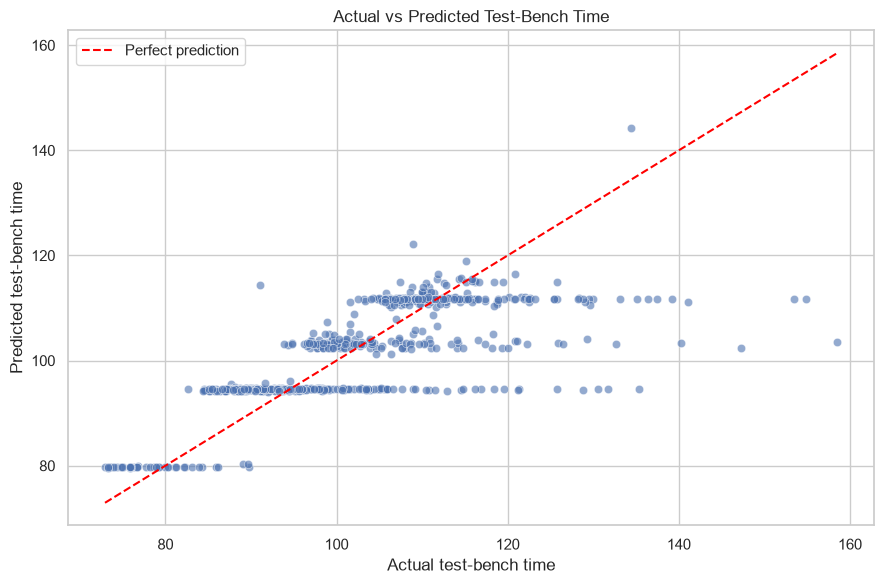

In [125]:
# 4. Compare actual and predicted test-bench times.

plt.figure(figsize=(9, 6))
sns.scatterplot(data=error_analysis, x="actual_time", y="predicted_time",alpha=0.6)

minimum_time = error_analysis[["actual_time", "predicted_time",]].min().min()

maximum_time = error_analysis[["actual_time","predicted_time"]].max().max()

plt.plot([minimum_time, maximum_time], [minimum_time, maximum_time], color="red", linestyle="--", label="Perfect prediction",)

plt.title("Actual vs Predicted Test-Bench Time")

plt.xlabel("Actual test-bench time")

plt.ylabel("Predicted test-bench time")

plt.legend()

plt.tight_layout()

plt.show()

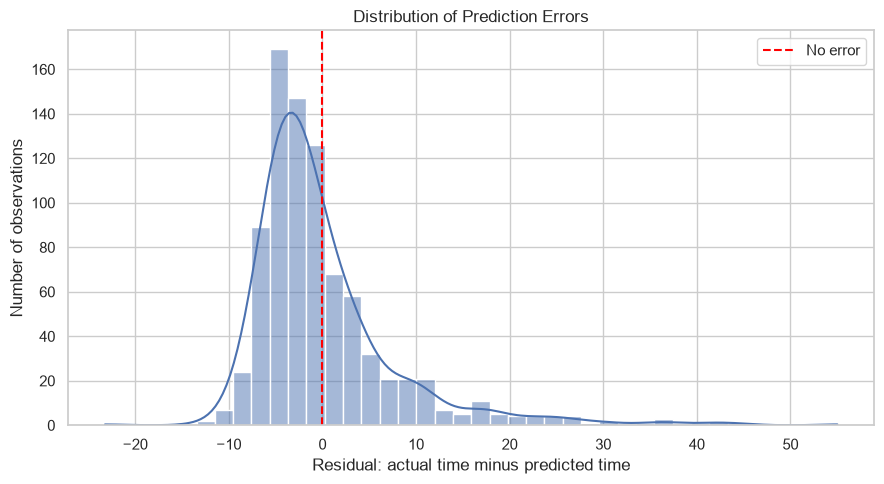

In [126]:
# 5. Display the distribution of residuals.

plt.figure(
    figsize=(9, 5)
)

sns.histplot(
    data=error_analysis,
    x="residual",
    bins=40,
    kde=True,
)

plt.axvline(
    x=0,
    color="red",
    linestyle="--",
    label="No error",
)

plt.title(
    "Distribution of Prediction Errors"
)

plt.xlabel(
    "Residual: actual time minus predicted time"
)

plt.ylabel(
    "Number of observations"
)

plt.legend()

plt.tight_layout()

plt.show()

In [ ]:
# 6. Find the ten largest prediction errors.

largest_errors = error_analysis.sort_values(by="absolute_error", ascending=False).head(10)

largest_errors.round(2)

,actual_time,predicted_time,residual,absolute_error
443,158.53,103.52,55.01,55.01
314,147.22,102.34,44.88,44.88
712,154.87,111.71,43.16,43.16
816,153.51,111.71,41.80,41.80
709,135.29,94.56,40.73,40.73
472,131.69,94.67,37.02,37.02
13,140.25,103.40,36.85,36.85
829,130.60,94.56,36.04,36.04
748,128.76,94.33,34.43,34.43
339,125.72,94.56,31.16,31.16


Schritt 7: Fehler für normale und hohe Prüfstandzeiten vergleichen

In [128]:
# 7. Mark unusually high test-bench times.

error_analysis["time_group"] = np.where(
    error_analysis["actual_time"] > upper_bound,
    "Unusually high time",
    "Regular time",
)

error_analysis["time_group"].value_counts()

time_group
Regular time           833
Unusually high time      9
Name: count, dtype: int64

Schritt 8: Durchschnittlichen Fehler je Gruppe berechnen. (Calculate the average error per group)

In [129]:
# 8. Compare the mean absolute error between both groups.

error_by_group = error_analysis.groupby(
    "time_group"
)["absolute_error"].agg(
    [
        "count",
        "mean",
        "median",
        "max",
    ]
)

error_by_group.round(2)

,count,mean,median,max
time_group,,,,
Regular time,833,4.95,3.86,40.73
Unusually high time,9,36.63,36.85,55.01


### Error Analysis

The tuned Gradient Boosting model performs reasonably well for
regular test-bench times. For these observations, the mean absolute
error is 4.95 time units.

However, the model has difficulty predicting unusually long tests.
For validation observations above the IQR upper boundary, the mean
absolute error increases to 36.63 time units. This error is
approximately 7.4 times higher than the error for regular test times.

The residual distribution is right-skewed, and the observations with
the largest errors have positive residuals. This indicates that the
model systematically underpredicts unusually long test-bench times.

This limitation is important for the potential data product. The model
can support capacity planning for typical vehicle configurations, but
predictions for unusually long tests should be flagged for additional
review.
### Fehleranalyse

Das optimierte Gradient-Boosting-Modell liefert bei regulären Prüfstandslaufzeiten gute Ergebnisse. Für diese Beobachtungen beträgt der mittlere absolute Fehler 4,95 Zeiteinheiten.

Das Modell hat jedoch Schwierigkeiten, ungewöhnlich lange Testläufe vorherzusagen. Bei Validierungsbeobachtungen, die über der oberen Grenze des Interquartilsabstands (IQR) liegen, steigt der mittlere absolute Fehler auf 36,63 Zeiteinheiten an. Dieser Fehler ist etwa 7,4-mal höher als der Fehler bei regulären Laufzeiten.

Die Verteilung der Residuen ist rechtsschief, und die Beobachtungen mit den größten Fehlern weisen positive Residuen auf. Dies deutet darauf hin, dass das Modell ungewöhnlich lange Prüfstandslaufzeiten systematisch unterschätzt.

Diese Einschränkung ist für das potenzielle Datenprodukt von Bedeutung. Das Modell kann zwar die Kapazitätsplanung für typische Fahrzeugkonfigurationen unterstützen, doch sollten Vorhersagen für ungewöhnlich lange Testläufe gekennzeichnet werden, um eine zusätzliche Überprüfung zu ermöglichen.

### Finales Modell trainieren (Train the final model)

Schritt 1: Vollständige Modelldaten vorbereiten

In [130]:
# 1. Prepare all available training features.

X_full = train_df.drop(columns=[ID_COLUMN, TARGET])

y_full = train_df[TARGET]

Schritt 2: Konstante Spalten entfernen

In [131]:
# 2. Remove the constant columns.

X_full_clean = X_full.drop(columns=constant_columns)

X_kaggle = test_df.drop(columns=[ID_COLUMN])

X_kaggle_clean = X_kaggle.drop(columns=constant_columns)

In [132]:
# 3. Check that both datasets have identical columns.

print(
    "Full training shape:",
    X_full_clean.shape,
)

print(
    "Kaggle test shape:",
    X_kaggle_clean.shape,
)

print(
    "Columns are identical:",
    X_full_clean.columns.equals(
        X_kaggle_clean.columns
    ),
)

Full training shape: (4209, 363)
Kaggle test shape: (4209, 363)
Columns are identical: True


Schritt 3: Finales Modell erstellen

In [134]:
# 4. Import the clone function.

from sklearn.base import clone

# 5. Create an unfitted copy of the tuned model.

final_model = clone(
    tuned_gradient_boosting_pipeline
)

Schritt 4: Dieselben Modellspalten auswählen

In [137]:
# 6. Get the columns used during model tuning.

model_columns = (
    X_train_clean.columns.tolist()
)

print(
    "Number of model columns:",
    len(model_columns),
)

Number of model columns: 364


Schritt 5: Vollständige Trainingsdaten vorbereiten

In [138]:
# 7. Select the model columns from the complete training data.

X_full_clean = train_df[
    model_columns
].copy()

y_full = train_df[
    TARGET
].copy()

Schritt 6: Kaggle-Testdaten vorbereiten

In [139]:
# 8. Select the same columns from the Kaggle test data.

X_kaggle_clean = test_df[
    model_columns
].copy()

Schritt 7: Daten kontrollieren

In [140]:
# 9. Check the prepared datasets.

print(
    "Full training shape:",
    X_full_clean.shape,
)

print(
    "Kaggle test shape:",
    X_kaggle_clean.shape,
)

print(
    "Columns are identical:",
    X_full_clean.columns.equals(
        X_kaggle_clean.columns
    ),
)

print(
    "X288 is available:",
    "X288" in X_full_clean.columns,
)

Full training shape: (4209, 364)
Kaggle test shape: (4209, 364)
Columns are identical: True
X288 is available: True


Schritt 8: Finales Modell trainieren

In [141]:
# 10. Train the final model using all training observations.

final_model.fit(X_full_clean, y_full)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](364,)","['X0','X1','X2',...,'X383','X384','X385']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,364
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numerical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concate

In [142]:
# 11. Predict the test-bench time for the Kaggle test data.

kaggle_predictions = final_model.predict(
    X_kaggle_clean
)

print(
    "Number of predictions:",
    len(kaggle_predictions),
)


Number of predictions: 4209


In [143]:
# 12. Create the final submission table.

final_submission = submission_df.copy()

final_submission[TARGET] = (
    kaggle_predictions
)

final_submission.head()

,ID,y
0,1,85.791620
1,2,101.228864
2,3,85.791620
3,4,79.949912
4,5,111.858412


In [144]:
# 13. Check the final submission.

print(
    "Submission shape:",
    final_submission.shape,
)

print(
    "Missing predictions:",
    final_submission[TARGET].isna().sum(),
)

print(
    "Minimum prediction:",
    final_submission[TARGET].min(),
)

print(
    "Maximum prediction:",
    final_submission[TARGET].max(),
)

Submission shape: (4209, 2)
Missing predictions: 0
Minimum prediction: 79.31590779849564
Maximum prediction: 137.96086027659345


In [145]:
# 14. Display the first five predictions.

final_submission.head()

,ID,y
0,1,85.791620
1,2,101.228864
2,3,85.791620
3,4,79.949912
4,5,111.858412


In [146]:
# 15. Display the last five predictions.

final_submission.tail()

,ID,y
4204,8410,103.675499
4205,8411,94.478067
4206,8413,94.352131
4207,8414,111.858412
4208,8416,94.478067


In [147]:
# 16. Create a folder for the prediction file.

PREDICTIONS_DIR = Path("data/predictions")

PREDICTIONS_DIR.mkdir(parents=True,exist_ok=True)


In [148]:
# 17. Define the submission file path.

submission_file = (
    PREDICTIONS_DIR
    / "gradient_boosting_submission.csv"
)

In [149]:
# 18. Save the submission without an additional index.

final_submission.to_csv(
    submission_file,
    index=False,
)

print(
    "Submission saved to:",
    submission_file,
)

Submission saved to: data\predictions\gradient_boosting_submission.csv


In [150]:
# 19. Load the saved submission for a final check.

saved_submission = pd.read_csv(
    submission_file
)

print(
    "Saved submission shape:",
    saved_submission.shape,
)

saved_submission.head()

Saved submission shape: (4209, 2)


,ID,y
0,1,85.791620
1,2,101.228864
2,3,85.791620
3,4,79.949912
4,5,111.858412
